## EOPF Dataset Zarr manipulation

In [ ]:
import os
import glob
import natsort
import xarray as xr
import sys

## Import custom functions

In [ ]:
sys.path.append('../')
from data.healpix import *
from utils.plot import plot_all_chunks

In [28]:
version = "V4"
TRAIN_DIR = f"/mnt/disk/dataset/sentinel-ai-processor/{version}/train/input"

In [20]:
zarr_path = natsort.natsorted(glob.glob(os.path.join(TRAIN_DIR, "*.zarr"), recursive=False))

In [31]:
# open .zarr datatree
dt = xr.open_datatree(zarr_path[11], engine="zarr", mask_and_scale=False, chunks={})

## Plot all chunks for a given resolution

Chunk size: y=1830, x=1830
Number of chunks: y=6, x=6


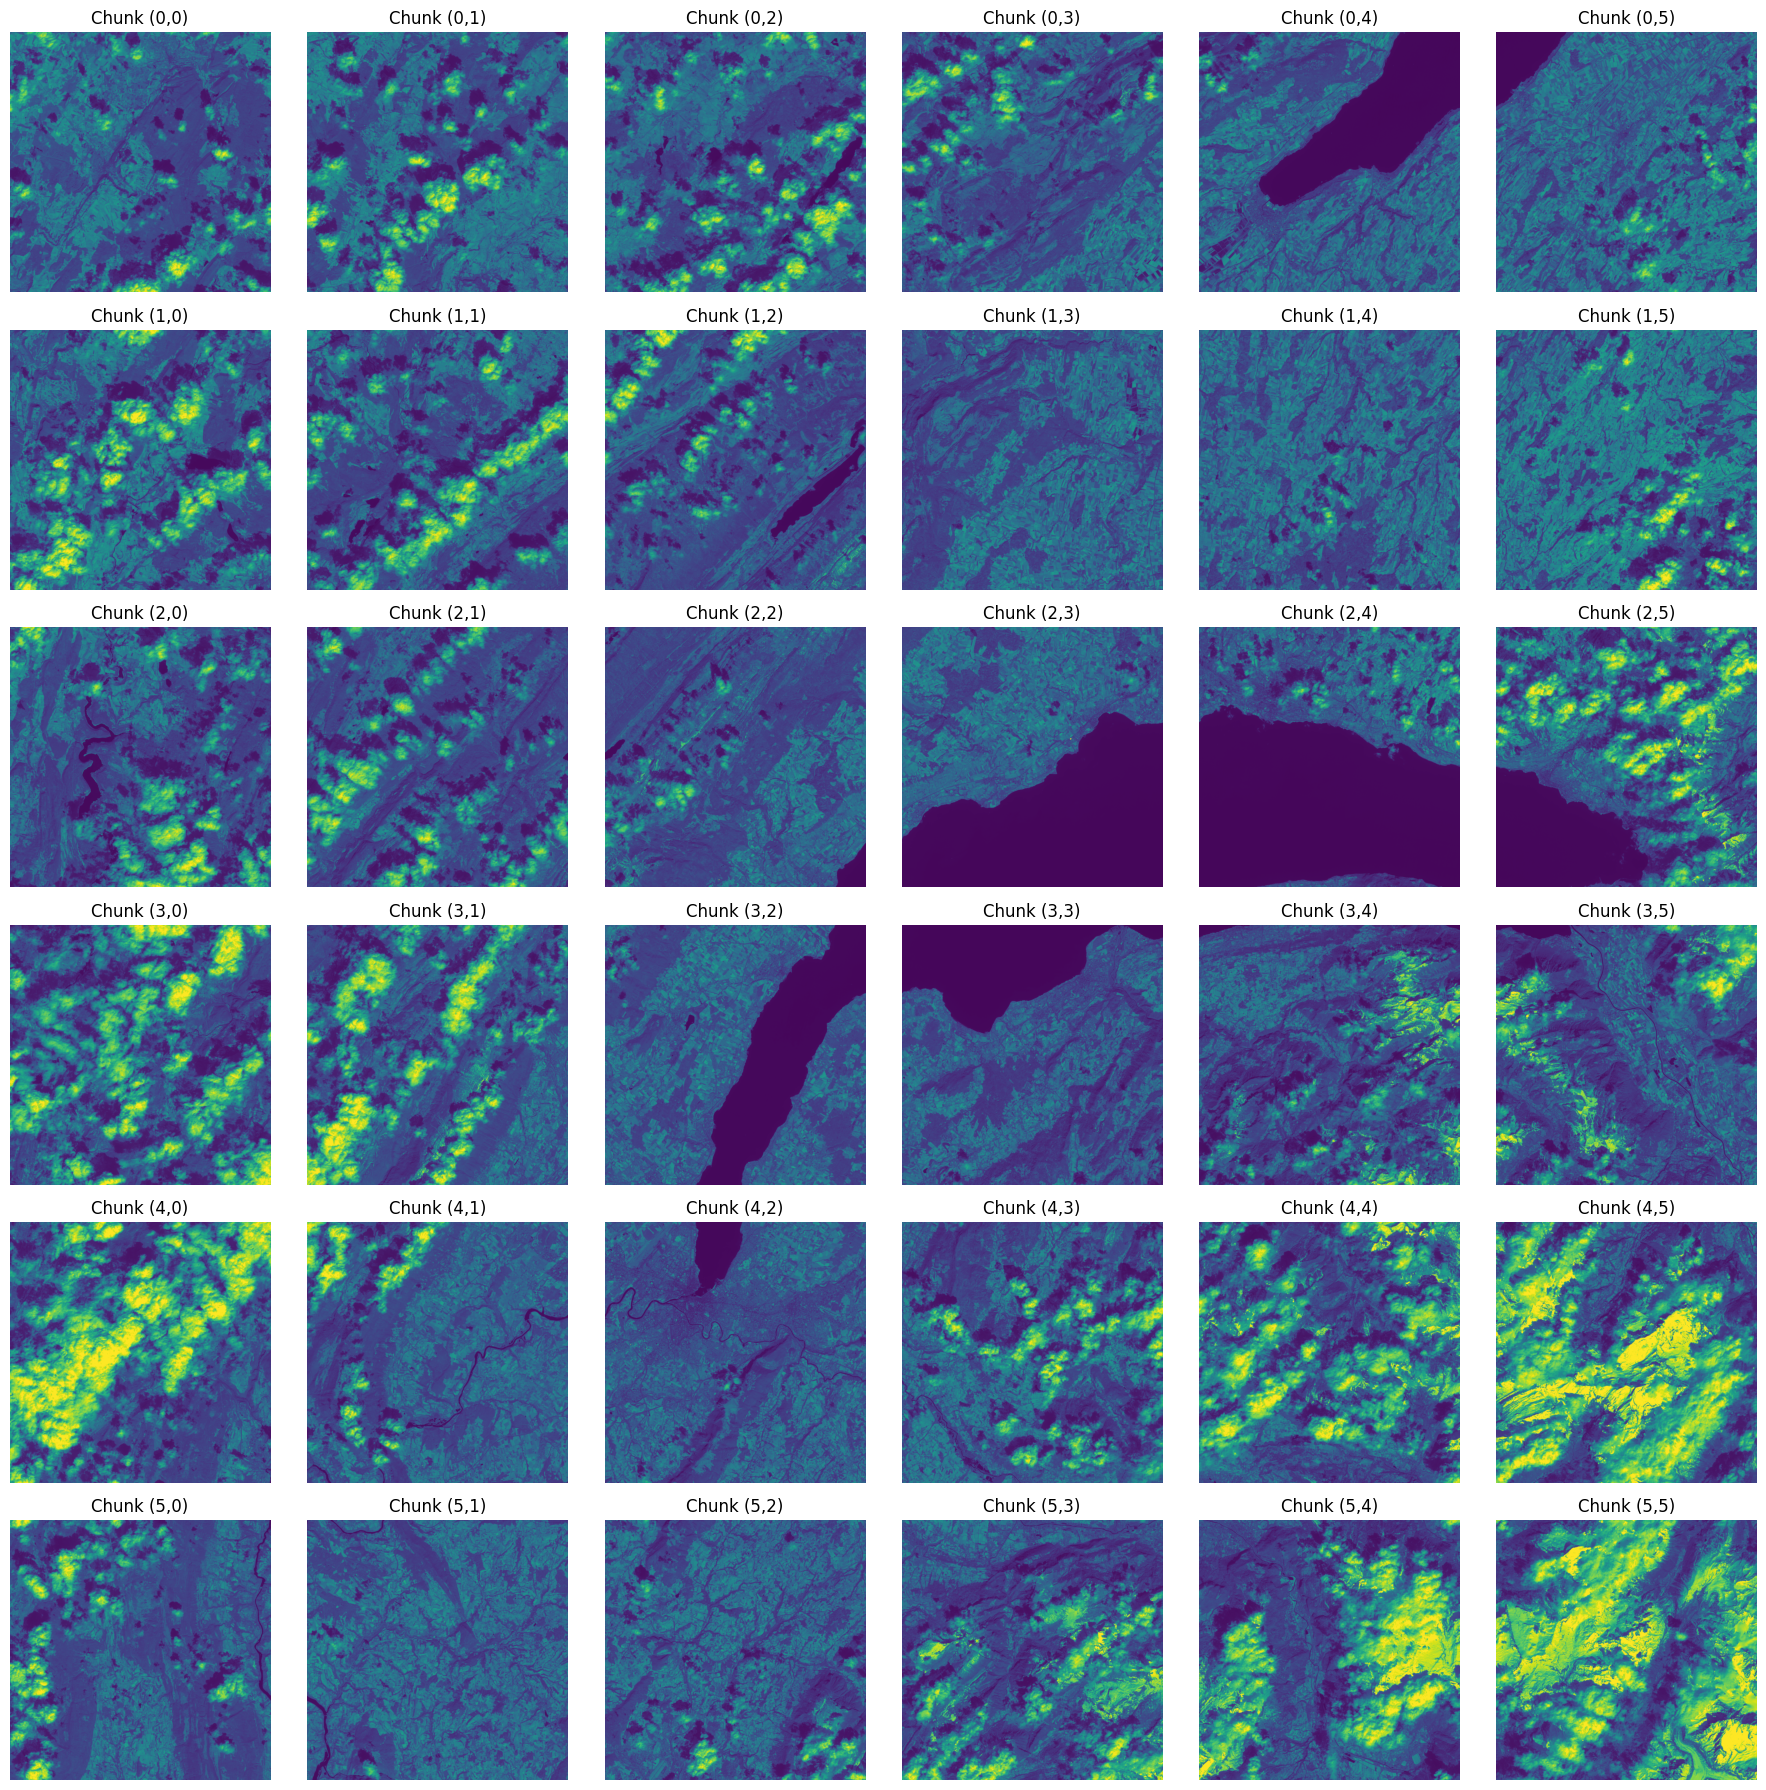

In [29]:
res = "10m"
band = "b08"
chunk_size_y, chunk_size_x, nb_chunks_y, nb_chunks_x = get_chunk_info(data_tree=dt, band=band, res=res)
plot_all_chunks(dt, band, res, chunk_size_y, chunk_size_x, nb_chunks_y, nb_chunks_x, cmap="viridis", verbose= True, figsize_scale=3)

## Get a chunk a DGGS transformation

In [33]:
level = 19
chunk_size = 4096
chunk_y_idx = 5
chunk_x_idx = 5
band_list = get_bands(data_tree=dt, res=res)
chunk_size_y, chunk_size_x, nb_chunks_y, nb_chunks_x = get_chunk_info(data_tree=dt, band=band_list[0], res=res)
chunk = get_chunk(data_tree=dt, res=res,
                  chunk_size_y=chunk_size_y,
                  chunk_size_x=chunk_size_x,
                  chunk_y_idx=chunk_y_idx,
                  chunk_x_idx=chunk_x_idx).load()

ds_healpix = healpix_projection(chunk, level=level, chunk_size=chunk_size)

Chunk size: y=1830, x=1830
Number of chunks: y=6, x=6
Coordinate grid shape: (1830, 1830)
X range: 791465 to 809755
Y range: 5090225 to 5108515
HEALPix Level 19 → 2,158,232 unique cells
Processing 4 variables: ['b02', 'b03', 'b04', 'b08']
Processing b02 (1/4)
Processing b03 (2/4)
Processing b04 (3/4)
Processing b08 (4/4)
HEALPix conversion complete - Level 19, 2,158,232 cells


## Chunk visualization with lonboard

In [34]:
import lonboard
from utils.healpix_plot import *

lonboard.Map(
    [
        exploire_layer(
            ds_healpix.Sentinel2.sel(bands=band_list[-1]).compute(),
            alpha=0.80,
            cmap='viridis'
        )

    ]
)

Map(custom_attribution='', layers=(SolidPolygonLayer(filled=True, get_fill_color=arro3.core.ChunkedArray<Fixed…